In [1]:
# IMPORTS

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
warnings.filterwarnings("ignore")    

2026-04-01 15:36:21.452811: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775057781.713138      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775057781.782794      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775057782.358089      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775057782.358124      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775057782.358127      55 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path = Path("/kaggle/input/datasets/marthakachweka/cell-data/cell_images")

label_map = {
    "Parasitized": ("parasite", 0),
    "Uninfected": ("non_parasite", 1)
}

records = []
for folder_name, (label, class_id) in label_map.items():
    folder_path = dataset_path / folder_name
    images = list(folder_path.glob("*.*"))
    print(f"{folder_name}: {len(images)} files found")
    
    for img_path in images:
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif"]:
            records.append({
                "filename": str(img_path),
                "label": label,
                "class_id": class_id
            })

df = pd.DataFrame(records)
df.to_csv("/kaggle/working/CELLimages_annotations.csv", index=False)

print(f"\nTotal annotated: {len(df)}")
print(df["label"].value_counts())
print(df.head())


Parasitized: 13780 files found
Uninfected: 13780 files found

Total annotated: 27558
label
parasite        13779
non_parasite    13779
Name: count, dtype: int64
                                            filename     label  class_id
0  /kaggle/input/datasets/marthakachweka/cell-dat...  parasite         0
1  /kaggle/input/datasets/marthakachweka/cell-dat...  parasite         0
2  /kaggle/input/datasets/marthakachweka/cell-dat...  parasite         0
3  /kaggle/input/datasets/marthakachweka/cell-dat...  parasite         0
4  /kaggle/input/datasets/marthakachweka/cell-dat...  parasite         0


2026-03-30 23:31:15.438795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774913475.874871      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774913475.986533      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774913477.101479      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774913477.101522      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774913477.101524      55 computation_placer.cc:177] computation placer alr

Total images: 27558
Parasitized: 13779
Uninfected: 13779

Dataset sizes:
Train: 20668
Validation: 2756
Test: 4134

Class distribution:
Train: [10334 10334]
Validation: [1378 1378]
Test: [2067 2067]


I0000 00:00:1774913514.298046      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774913514.304167      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


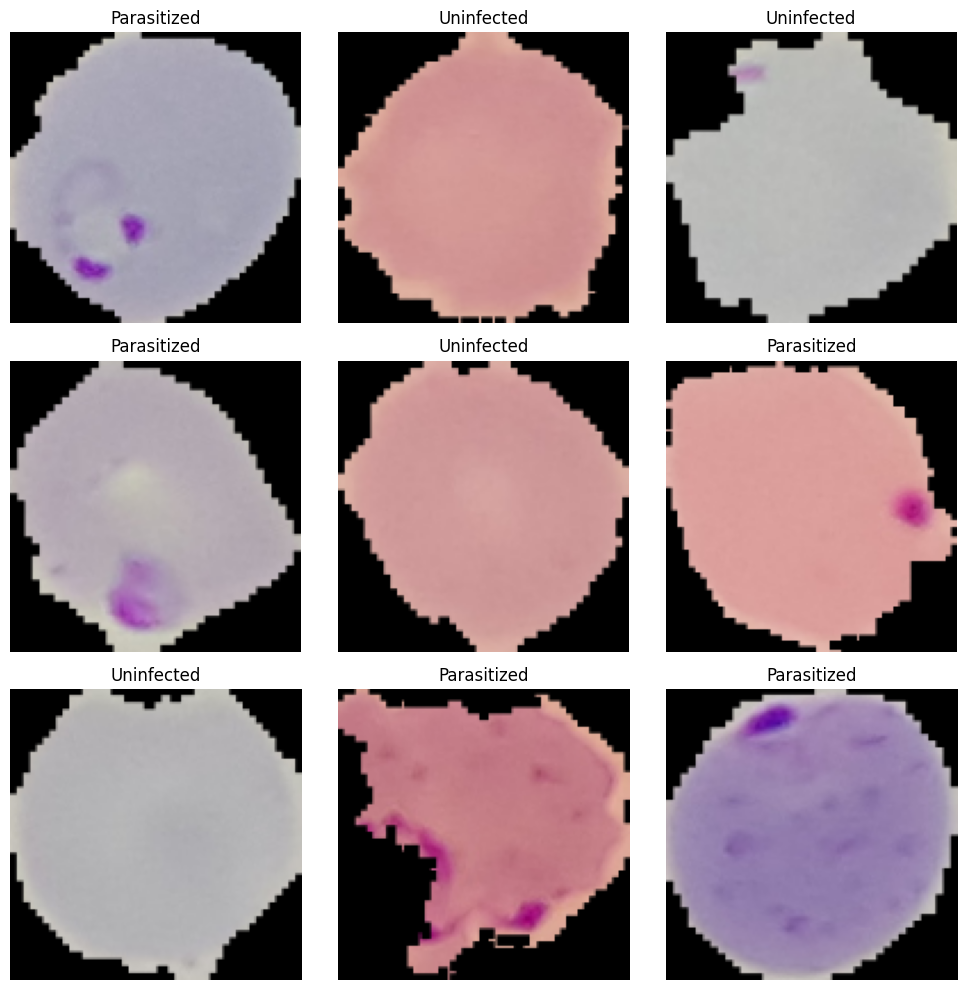

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


I0000 00:00:1774913577.823138     135 service.cc:152] XLA service 0x7c5bc45acf80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774913577.823175     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774913577.823180     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774913578.308316     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


  16/1292 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.5545 - loss: 1.0938

I0000 00:00:1774913582.373108     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1292/1292 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.5877 - loss: 0.6716 - val_accuracy: 0.9369 - val_loss: 0.1977
Epoch 2/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9504 - loss: 0.1625 - val_accuracy: 0.9630 - val_loss: 0.1216
Epoch 3/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.9578 - loss: 0.1264 - val_accuracy: 0.9579 - val_loss: 0.1185
Epoch 4/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.9644 - loss: 0.1067 - val_accuracy: 0.9626 - val_loss: 0.1161
Epoch 5/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9689 - loss: 0.0890 - val_accuracy: 0.9612 - val_loss: 0.1163
Epoch 6/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9770 - loss: 0.0695 - val_accuracy: 0.9594 - val_loss: 0.1313
Epoch 7/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9806 - loss: 0.0574 - val_accuracy: 0.9641 - val_loss: 0.1491
Epoch 8/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9862 - loss: 0.03

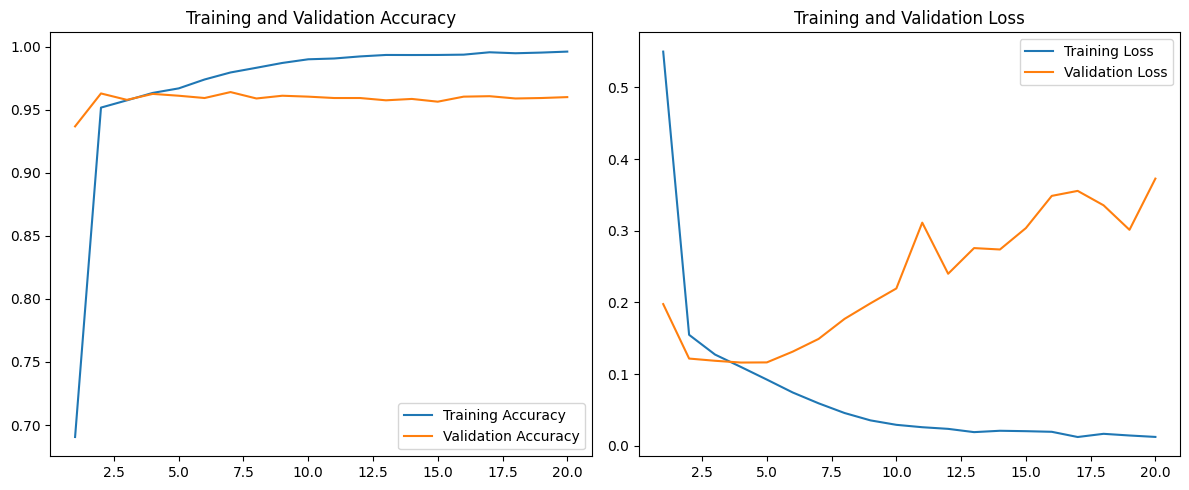

259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.9548 - loss: 0.4440

Test Loss: 0.5046
Test Accuracy: 0.9509

Unique values in y_true: [0 1]
Unique values in y_pred: [0 1]
Class names: ['Parasitized', 'Uninfected']

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.96      0.94      0.95      2067
  Uninfected       0.94      0.96      0.95      2067

    accuracy                           0.95      4134
   macro avg       0.95      0.95      0.95      4134
weighted avg       0.95      0.95      0.95      4134



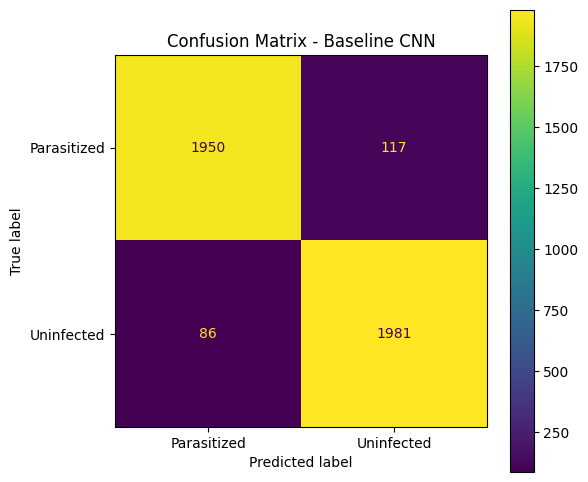

In [4]:
data_dir = "/kaggle/input/datasets/marthakachweka/cell-data/cell_images"
img_size = (128, 128)
batch_size = 16
seed = 42
epochs = 20

class_names = ["Parasitized", "Uninfected"]

parasitized_dir = os.path.join(data_dir, "Parasitized")
uninfected_dir = os.path.join(data_dir, "Uninfected")

parasitized_files = [
    os.path.join(parasitized_dir, f)
    for f in os.listdir(parasitized_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

uninfected_files = [
    os.path.join(uninfected_dir, f)
    for f in os.listdir(uninfected_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

filepaths = parasitized_files + uninfected_files
labels = [0] * len(parasitized_files) + [1] * len(uninfected_files)

print("Total images:", len(filepaths))
print("Parasitized:", len(parasitized_files))
print("Uninfected:", len(uninfected_files))


X_temp, X_test, y_temp, y_test = train_test_split(
    filepaths,
    labels,
    test_size=0.15,
    random_state=seed,
    stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=10/85,  
    random_state=seed,
    stratify=y_temp
)

print("\nDataset sizes:")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nClass distribution:")
print("Train:", np.bincount(y_train))
print("Validation:", np.bincount(y_val))
print("Test:", np.bincount(y_test))


def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(filepaths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(X_test, y_test, training=False)


plt.figure(figsize=(10, 10))
for images, labels_batch in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels_batch[i].numpy())])
        plt.axis("off")
plt.tight_layout()
plt.show()

# Build baseline CNN
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_true = []
y_pred_prob = []

for images, labels_batch in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels_batch.numpy())
    y_pred_prob.extend(preds.flatten())

y_true = np.array(y_true).astype(int)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nUnique values in y_true:", np.unique(y_true))
print("Unique values in y_pred:", np.unique(y_pred))
print("Class names:", class_names)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title("Confusion Matrix - Baseline CNN")
plt.show()

## Augmented Datasets

In [3]:
# AUGMENTATION — Resize to 128×128 + Horizontal Flip only
# ═══════════════════════════════════════════════════════════════
import os
import random
import warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import pandas as pd
from pathlib import Path
from PIL import Image

random.seed(42)

source_dir = Path("/kaggle/input/datasets/marthakachweka/cell-data/cell_images")
save_dir   = Path("/kaggle/working/augmented_horizontal_128")

TARGET_SIZE = (128, 128)

def augment_image(img):
    augmented = []
    augmented.append(img.transpose(Image.FLIP_LEFT_RIGHT))
    return augmented 

records = []

for class_name in ["Parasitized", "Uninfected"]:
    src_class_dir  = source_dir / class_name
    save_class_dir = save_dir / class_name
    save_class_dir.mkdir(parents=True, exist_ok=True)

    images = [f for f in src_class_dir.glob("*.*")
              if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]

    print(f"{class_name}: {len(images)} originals → {len(images) * 2} total (original + horizontal flip)")

    for img_path in images:
        try:
            img = Image.open(img_path).convert("RGB").resize(TARGET_SIZE)

            orig_save_path = save_class_dir / f"{img_path.stem}.png"
            img.save(str(orig_save_path))
            records.append({
                "filepath": str(orig_save_path),
                "label"   : 1 if class_name == "Parasitized" else 0,
                "type"    : "original"
            })

            for i, aug_img in enumerate(augment_image(img)):
                save_path = save_class_dir / f"{img_path.stem}_flip{i+1}.png"
                aug_img.save(str(save_path))
                records.append({
                    "filepath": str(save_path),
                    "label"   : 1 if class_name == "Parasitized" else 0,
                    "type"    : "horizontal_flip"
                })

        except Exception as e:
            print(f"  Skipped {img_path.name}: {e}")

aug_df = pd.DataFrame(records)
aug_df.to_csv("/kaggle/working/augmented_horizontal_128.csv", index=False)

print(f"\n COMPLETE")
print(f"Total images : {len(aug_df)}")
print(aug_df["label"].value_counts())
print(aug_df["type"].value_counts())
print(f"\nCSV saved    : /kaggle/working/augmented_annotations_128.csv")
print(f"Images saved : {save_dir}")



Parasitized: 13779 originals → 27558 total (original + horizontal flip)
Uninfected: 13779 originals → 27558 total (original + horizontal flip)

✅ COMPLETE
Total images : 55116
label
1    27558
0    27558
Name: count, dtype: int64
type
original           27558
horizontal_flip    27558
Name: count, dtype: int64

CSV saved    : /kaggle/working/augmented_annotations_128.csv
Images saved : /kaggle/working/augmented_horizontal_128


In [4]:
from pathlib import Path

folder = Path("/kaggle/working/augmented_horizontal_128")
print(f"Exists : {folder.exists()}")
print(f"Parasitized images : {len(list((folder / 'Parasitized').glob('*.png')))}")
print(f"Uninfected images  : {len(list((folder / 'Uninfected').glob('*.png')))}")

Exists : True
Parasitized images : 27558
Uninfected images  : 27558


In [3]:
import shutil

zip_path = shutil.make_archive(
    base_name='/kaggle/working/augmented_horizontal_128',  # output zip filename
    format='zip',
    root_dir='/kaggle/working',
    base_dir='augmented_horizontal_128' 
)

print(f"ZIP saved: {zip_path}")

ZIP saved: /kaggle/working/augmented_horizontal_128.zip


In [11]:
import os

for root, dirs, files in os.walk("/kaggle/working/augmented_horizontal_128"):
    level = root.replace("/kaggle/input/datasets/marthakachweka", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3: 
        for f in files[:3]:  
            print(f"  {indent}{f}")

marthakachweka/
  augmented-128-size/
    augmented_horizontal_128.csv
  augmented-data/
    labels_augmented.csv
    Uninfected/
      C60P21thinF_IMG_20150803_144003_cell_105_aug2.png
      C203ThinF_IMG_20151029_102123_cell_51.png
      C64P25N_ThinF_IMG_20150818_153517_cell_49_aug5.png
    Parasitized/
      C99P60ThinF_IMG_20150918_142128_cell_104_aug6.png
      C182P143NThinF_IMG_20151201_172216_cell_154_aug1.png
      C133P94ThinF_IMG_20151004_154351_cell_113_aug10.png
  cell-data/
    cell_images/
      Uninfected/
      Parasitized/


In [12]:
import os
for root, dirs, files in os.walk("/kaggle/working/augmented_horizontal_128"):
    if "augmented_horizontal_128" in root and files:
        print(root)
        break

/kaggle/working/augmented_horizontal_128/Uninfected


## model train(Baseline CNN) on augmented dataset

Total images: 55116
Parasitized: 27558
Uninfected: 27558

Dataset sizes:
Train: 41336
Validation: 5512
Test: 8268

Class distribution:
Train: [20668 20668]
Validation: [2756 2756]
Test: [4134 4134]


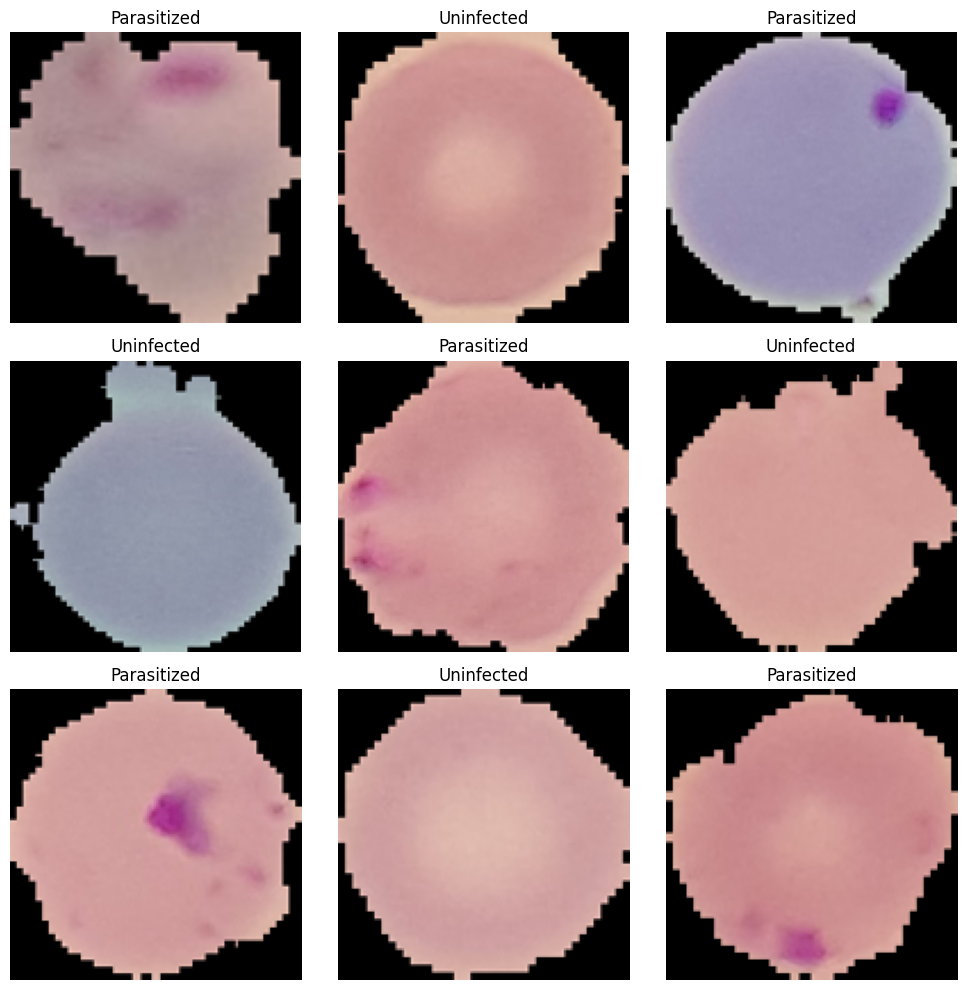

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2583/2584 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8590 - loss: 0.3296

2026-03-30 23:57:23.356079: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-30 23:57:23.499325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2584/2584 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - accuracy: 0.8591 - loss: 0.3295 - val_accuracy: 0.9512 - val_loss: 0.1554
Epoch 2/20
2584/2584 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.9564 - loss: 0.1396 - val_accuracy: 0.9521 - val_loss: 0.1351
Epoch 3/20
2584/2584 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9595 - loss: 0.1248 - val_accuracy: 0.9525 - val_loss: 0.1384
Epoch 4/20
2584/2584 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9636 - loss: 0.1080 - val_accuracy: 0.9552 - val_loss: 0.1321
Epoch 5/20
2584/2584 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9659 - loss: 0.0999 - val_accuracy: 0.9554 - val_loss: 0.1433
Epoch 6/20
2584/2584 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9697 - loss: 0.0849 - val_accuracy: 0.9530 - val_loss: 0.1498
Epoch 7/20
2584/2584 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9747 - loss: 0.0717 - val_accuracy: 0.9523 - val_loss: 0.1741
Epoch 8/20
2584/2584 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9783 - loss: 0.05

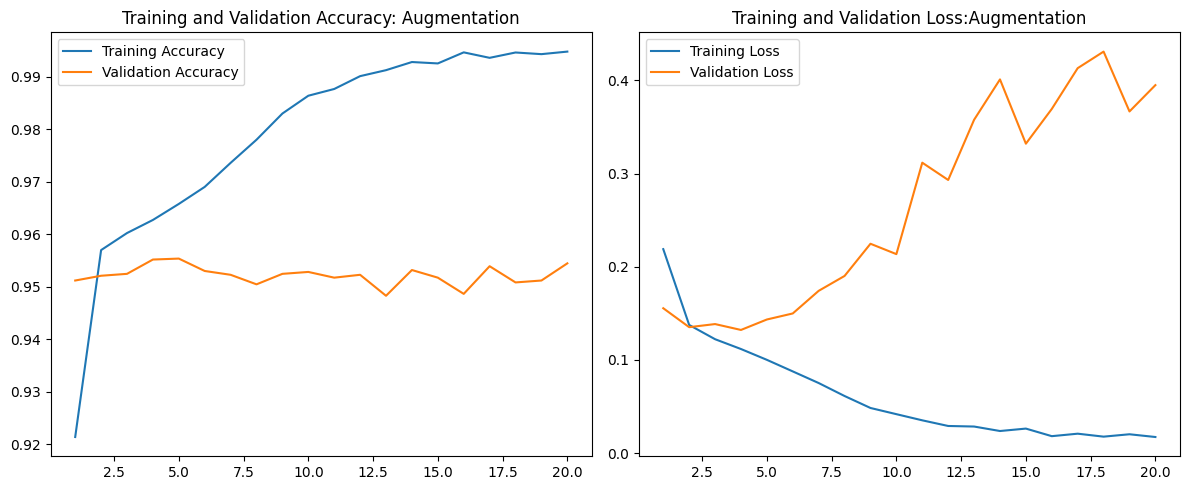

517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9559 - loss: 0.3219

Test Loss: 0.3367
Test Accuracy: 0.9572

Unique values in y_true: [0 1]
Unique values in y_pred: [0 1]
Class names: ['Parasitized', 'Uninfected']

Classification Report (AUGMENTED DATASET):
              precision    recall  f1-score   support

 Parasitized       0.96      0.95      0.96      4134
  Uninfected       0.95      0.96      0.96      4134

    accuracy                           0.96      8268
   macro avg       0.96      0.96      0.96      8268
weighted avg       0.96      0.96      0.96      8268



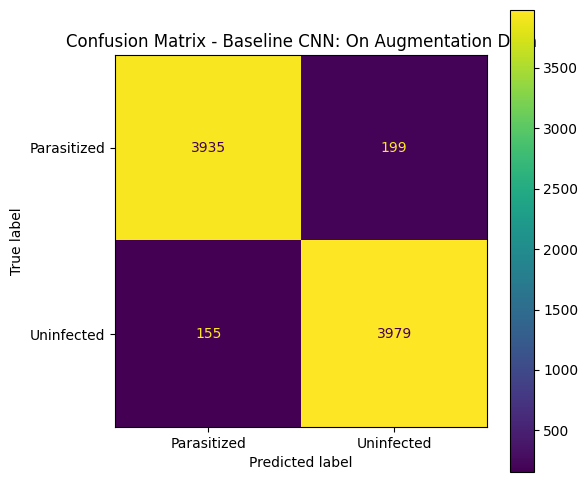

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


data_dir = "/kaggle/working/augmented_horizontal_128"
img_size = (128, 128)
batch_size = 16
seed = 42
epochs = 20


class_names = ["Parasitized", "Uninfected"]

parasitized_dir = os.path.join(data_dir, "Parasitized")
uninfected_dir = os.path.join(data_dir, "Uninfected")

parasitized_files = [
    os.path.join(parasitized_dir, f)
    for f in os.listdir(parasitized_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

uninfected_files = [
    os.path.join(uninfected_dir, f)
    for f in os.listdir(uninfected_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

filepaths = parasitized_files + uninfected_files
labels = [0] * len(parasitized_files) + [1] * len(uninfected_files)

print("Total images:", len(filepaths))
print("Parasitized:", len(parasitized_files))
print("Uninfected:", len(uninfected_files))


X_temp, X_test, y_temp, y_test = train_test_split(
    filepaths,
    labels,
    test_size=0.15,
    random_state=seed,
    stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=10/85, 
    random_state=seed,
    stratify=y_temp
)

print("\nDataset sizes:")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nClass distribution:")
print("Train:", np.bincount(y_train))
print("Validation:", np.bincount(y_val))
print("Test:", np.bincount(y_test))

def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(filepaths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(X_test, y_test, training=False)

plt.figure(figsize=(10, 10))
for images, labels_batch in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels_batch[i].numpy())])
        plt.axis("off")
plt.tight_layout()
plt.show()

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy: Augmentation')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss:Augmentation')

plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

-
y_true = []
y_pred_prob = []

for images, labels_batch in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels_batch.numpy())
    y_pred_prob.extend(preds.flatten())

y_true = np.array(y_true).astype(int)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nUnique values in y_true:", np.unique(y_true))
print("Unique values in y_pred:", np.unique(y_pred))
print("Class names:", class_names)

print("\nClassification Report (AUGMENTED DATASET):")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title("Confusion Matrix - Baseline CNN: On Augmentation Data")
plt.show()

## Mobile Net:

Augmented dataset:
label
1    27558
0    27558
Name: count, dtype: int64

Train : 38580 (70.0%)
Val   : 8268  (15.0%)
Test  : 8268  (15.0%)
Found 38580 validated image filenames belonging to 2 classes.
Found 8268 validated image filenames belonging to 2 classes.
Found 8268 validated image filenames belonging to 2 classes.


I0000 00:00:1774972614.501778      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774972614.508023      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

2026-03-31 15:57:39.391020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 15:57:39.528439: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2412/2412 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9046 - loss: 0.2426

2026-03-31 15:59:05.497565: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 15:59:05.635211: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2412/2412 ━━━━━━━━━━━━━━━━━━━━ 131s 46ms/step - accuracy: 0.9046 - loss: 0.2426 - val_accuracy: 0.9413 - val_loss: 0.1609
Epoch 2/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9385 - loss: 0.1663 - val_accuracy: 0.9419 - val_loss: 0.1698
Epoch 3/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - accuracy: 0.9423 - loss: 0.1559 - val_accuracy: 0.9446 - val_loss: 0.1519
Epoch 4/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9441 - loss: 0.1512 - val_accuracy: 0.9433 - val_loss: 0.1547
Epoch 5/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - accuracy: 0.9476 - loss: 0.1451 - val_accuracy: 0.9502 - val_loss: 0.1420
Epoch 6/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - accuracy: 0.9472 - loss: 0.1464 - val_accuracy: 0.9491 - val_loss: 0.1364
Epoch 7/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 85s 35ms/step - accuracy: 0.9487 - loss: 0.1425 - val_accuracy: 0.9480 - val_loss: 0.1449
Epoch 8/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9521 - loss: 0.1


✓ Model saved to: mobilenetv2_malaria.h5
✓ Base model saved to: mobilenetv2_base.h5


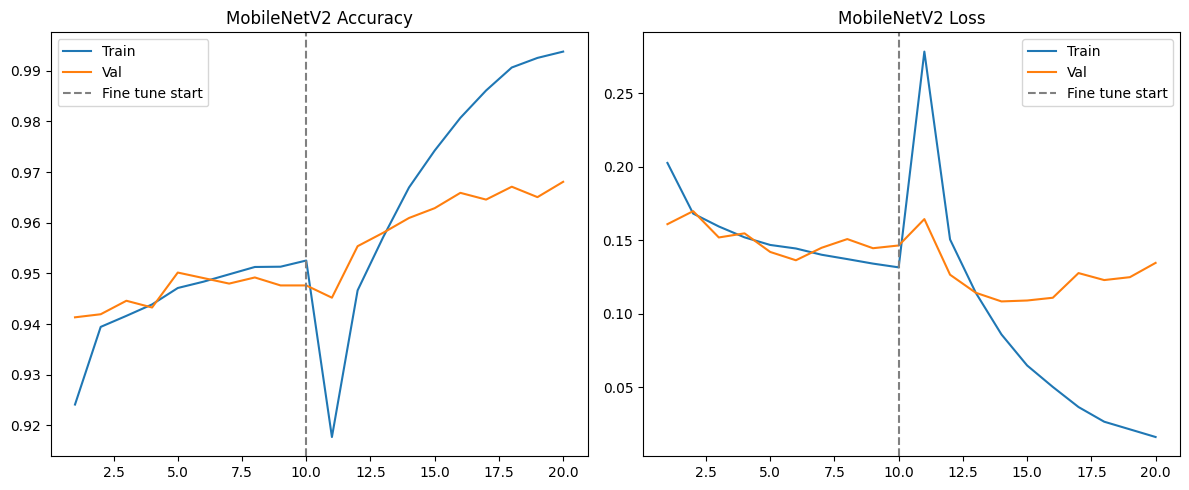

517/517 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.9679 - loss: 0.1292
517/517 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.9694 - loss: 0.1233

Val  Accuracy : 0.9681 | Val  Loss : 0.1346
Test Accuracy : 0.9688 | Test Loss : 0.1314
Test Loss     : 0.1314
Test Accuracy : 0.9688

Generating predictions...
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.96      0.97      0.97      4134
 Parasitized       0.97      0.96      0.97      4134

    accuracy                           0.97      8268
   macro avg       0.97      0.97      0.97      8268
weighted avg       0.97      0.97      0.97      8268



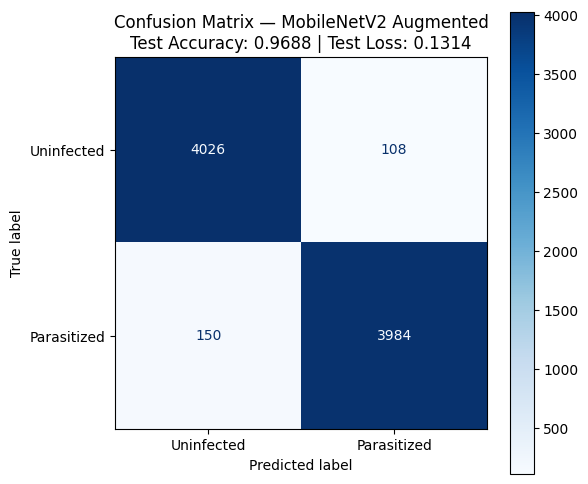

✓ Evaluation complete!


In [2]:
# MobileNetV2 — Transfer Learning on Augmented Dataset (55,116 images)
# ═══════════════════════════════════════════════════════════════════════════
import os
import warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

img_size   = (224, 224) 
BATCH_SIZE = 16
EPOCHS     = 20
seed       = 42

df = pd.read_csv("/kaggle/working/augmented_horizontal_128.csv")
df["label"] = df["label"].astype(str)
print("Augmented dataset:")
print(df["label"].value_counts())

X_temp, X_test, y_temp, y_test = train_test_split(
    df["filepath"].values, df["label"].values,
    test_size=0.15, random_state=seed, stratify=df["label"]
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=15/85, random_state=seed, stratify=y_temp
)

train_df = pd.DataFrame({"filepath": X_train, "label": y_train})
val_df   = pd.DataFrame({"filepath": X_val,   "label": y_val})
test_df  = pd.DataFrame({"filepath": X_test,  "label": y_test})

print(f"\nTrain : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df)}  ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df)}  ({len(test_df)/len(df)*100:.1f}%)")

def mobilenet_preprocess(x):
    return tf.keras.applications.mobilenet_v2.preprocess_input(x)

train_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)
val_datagen   = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=img_size, color_mode="rgb",
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=img_size, color_mode="rgb",
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=False
)
test_gen = val_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=img_size, color_mode="rgb",
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=False
)

def build_mobilenet():
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,       
        weights='imagenet'        
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)  # lightweight — no Flatten
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

model, base_model = build_mobilenet()
model.summary()

print(f"\nTotal params     : {model.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

print("\n── Phase 1: Training top layers (base frozen) ──")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10 
)

print("\n── Phase 2: Fine tuning (top 30 layers unfrozen) ──")
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10 
)

model.save('mobilenetv2_malaria.h5')
print("\n✓ Model saved to: mobilenetv2_malaria.h5")

base_model.save('mobilenetv2_base.h5')
print("✓ Base model saved to: mobilenetv2_base.h5")

acc      = history1.history['accuracy']      + history2.history['accuracy']
val_acc  = history1.history['val_accuracy']  + history2.history['val_accuracy']
loss     = history1.history['loss']          + history2.history['loss']
val_loss = history1.history['val_loss']      + history2.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc,     label='Train')
plt.plot(epochs_range, val_acc, label='Val')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine tune start')
plt.legend(); plt.title('MobileNetV2 Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss,     label='Train')
plt.plot(epochs_range, val_loss, label='Val')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine tune start')
plt.legend(); plt.title('MobileNetV2 Loss')
plt.tight_layout()
plt.show()

val_loss_score,  val_acc_score  = model.evaluate(val_gen)
test_loss_score, test_acc_score = model.evaluate(test_gen)
print(f"\nVal  Accuracy : {val_acc_score:.4f} | Val  Loss : {val_loss_score:.4f}")
print(f"Test Accuracy : {test_acc_score:.4f} | Test Loss : {test_loss_score:.4f}")

test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

print("\nGenerating predictions...")
y_pred_prob = model.predict(test_gen, verbose=1).flatten()
y_true = np.array(test_gen.labels).astype(int)
y_pred = (y_pred_prob >= 0.5).astype(int)

class_names = ["Uninfected", "Parasitized"]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title(f"Confusion Matrix — MobileNetV2 Augmented\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")
plt.savefig('confusion_matrix_mobilenet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation complete!")

Augmented dataset:
label
1    27558
0    27558
Name: count, dtype: int64

Train : 38580 (70.0%)
Val   : 8268  (15.0%)
Test  : 8268  (15.0%)
Found 38580 validated image filenames belonging to 2 classes.
Found 8268 validated image filenames belonging to 2 classes.
Found 8268 validated image filenames belonging to 2 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)


Total params     : 7,168,833
Trainable params : 131,329

── Phase 1: Training top layers (base frozen) ──
Epoch 1/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 194s 69ms/step - accuracy: 0.8749 - loss: 0.2958 - val_accuracy: 0.9297 - val_loss: 0.1804
Epoch 2/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 130s 54ms/step - accuracy: 0.9183 - loss: 0.2102 - val_accuracy: 0.9242 - val_loss: 0.1855
Epoch 3/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 129s 53ms/step - accuracy: 0.9285 - loss: 0.1886 - val_accuracy: 0.9353 - val_loss: 0.1620
Epoch 4/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 129s 54ms/step - accuracy: 0.9333 - loss: 0.1763 - val_accuracy: 0.9399 - val_loss: 0.1569
Epoch 5/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 130s 54ms/step - accuracy: 0.9365 - loss: 0.1702 - val_accuracy: 0.9365 - val_loss: 0.1615
Epoch 6/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 131s 54ms/step - accuracy: 0.9384 - loss: 0.1652 - val_accuracy: 0.9428 - val_loss: 0.1499
Epoch 7/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 133s 55ms/step - accuracy: 0.9424 - loss: 0.1577 - va

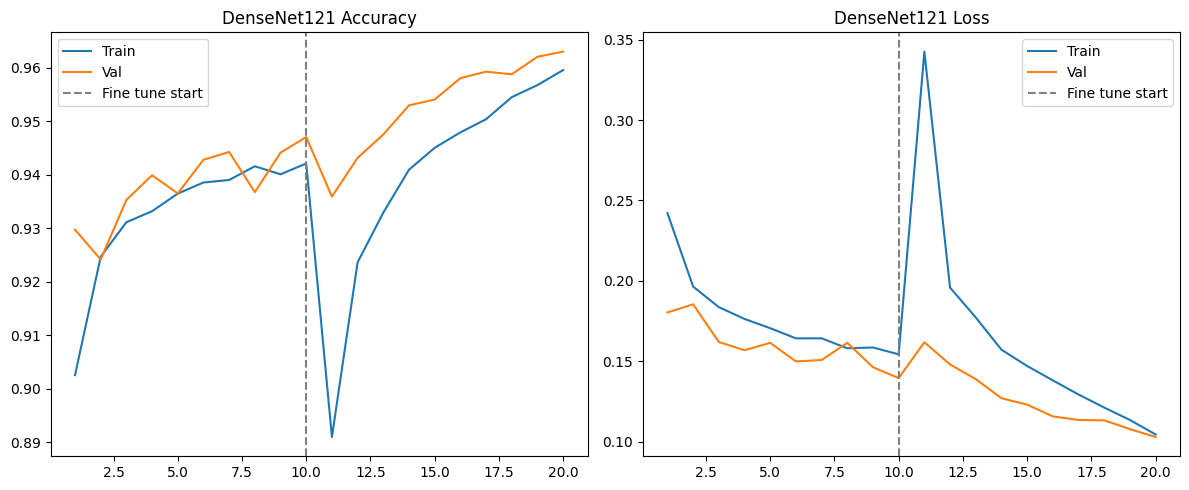

Test Loss     : 0.1002
Test Accuracy : 0.9623

Generating predictions...
517/517 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.96      0.97      0.96      4134
 Parasitized       0.97      0.96      0.96      4134

    accuracy                           0.96      8268
   macro avg       0.96      0.96      0.96      8268
weighted avg       0.96      0.96      0.96      8268



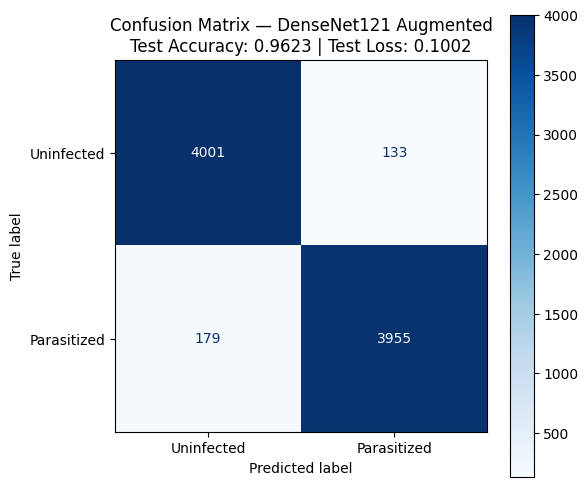

✓ Evaluation complete!


In [6]:
# DenseNet121 — Transfer Learning on Augmented Dataset (55,116 images)
# ═══════════════════════════════════════════════════════════════════════════
img_size   = (224, 224) 
BATCH_SIZE = 16
EPOCHS     = 20
seed       = 42

df = pd.read_csv("/kaggle/working/augmented_horizontal_128.csv")
df["label"] = df["label"].astype(str)
print("Augmented dataset:")
print(df["label"].value_counts())

X_temp, X_test, y_temp, y_test = train_test_split(
    df["filepath"].values, df["label"].values,
    test_size=0.15, random_state=seed, stratify=df["label"]
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=15/85, random_state=seed, stratify=y_temp
)

train_df = pd.DataFrame({"filepath": X_train, "label": y_train})
val_df   = pd.DataFrame({"filepath": X_val,   "label": y_val})
test_df  = pd.DataFrame({"filepath": X_test,  "label": y_test})

print(f"\nTrain : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df)}  ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df)}  ({len(test_df)/len(df)*100:.1f}%)")

def densenet_preprocess(x):
    return tf.keras.applications.densenet.preprocess_input(x)

train_datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess)
val_datagen   = ImageDataGenerator(preprocessing_function=densenet_preprocess)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=img_size, color_mode="rgb",
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=img_size, color_mode="rgb",
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=False
)
test_gen = val_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=img_size, color_mode="rgb",
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=False
)

def build_densenet():
    base_model = DenseNet121(
        input_shape=(224, 224, 3),
        include_top=False,       
        weights='imagenet'       
    )
    base_model.trainable = False 

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

model, base_model = build_densenet()
model.summary()

print(f"\nTotal params     : {model.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

print("\n── Phase 1: Training top layers (base frozen) ──")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

print("\n── Phase 2: Fine tuning (top 30 layers unfrozen) ──")
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc,     label='Train')
plt.plot(epochs_range, val_acc, label='Val')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine tune start')
plt.legend(); plt.title('DenseNet121 Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss,     label='Train')
plt.plot(epochs_range, val_loss, label='Val')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine tune start')
plt.legend(); plt.title('DenseNet121 Loss')
plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

print("\nGenerating predictions...")
y_pred_prob = model.predict(test_gen, verbose=1).flatten()
y_true = np.array(test_gen.labels).astype(int) 
y_pred = (y_pred_prob >= 0.5).astype(int)

class_names = ["Uninfected", "Parasitized"]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title(f"Confusion Matrix — DenseNet121 Augmented\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")
plt.savefig('confusion_matrix_densenet.png', dpi=150, bbox_inches='tight') 
plt.show()
print(" Evaluation complete!")

## VGG-16 mODEL

Augmented dataset:
label
1    27558
0    27558
Name: count, dtype: int64

Train : 38580 (70.0%)
Val   : 8268  (15.0%)
Test  : 8268  (15.0%)
Found 38580 validated image filenames belonging to 2 classes.
Found 8268 validated image filenames belonging to 2 classes.
Found 8268 validated image filenames belonging to 2 classes.


I0000 00:00:1774956815.589376      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774956815.595460      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...


Total params     : 14,879,041
Trainable params : 164,353

── Phase 1: Training top layers (base frozen) ──
Epoch 1/10


I0000 00:00:1774956819.528005     106 service.cc:152] XLA service 0x7cdf00010730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774956819.528042     106 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774956819.528045     106 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774956820.121696     106 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/2412 ━━━━━━━━━━━━━━━━━━━━ 3:48 95ms/step - accuracy: 0.6250 - loss: 1.3472  

I0000 00:00:1774956828.644555     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2412/2412 ━━━━━━━━━━━━━━━━━━━━ 347s 139ms/step - accuracy: 0.8914 - loss: 0.3329 - val_accuracy: 0.9503 - val_loss: 0.1562
Epoch 2/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 337s 140ms/step - accuracy: 0.9383 - loss: 0.1763 - val_accuracy: 0.9469 - val_loss: 0.1523
Epoch 3/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 336s 139ms/step - accuracy: 0.9435 - loss: 0.1620 - val_accuracy: 0.9526 - val_loss: 0.1494
Epoch 4/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 337s 140ms/step - accuracy: 0.9468 - loss: 0.1529 - val_accuracy: 0.9503 - val_loss: 0.1498
Epoch 5/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 336s 139ms/step - accuracy: 0.9467 - loss: 0.1518 - val_accuracy: 0.9457 - val_loss: 0.1474
Epoch 6/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 338s 140ms/step - accuracy: 0.9486 - loss: 0.1477 - val_accuracy: 0.9543 - val_loss: 0.1426
Epoch 7/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 337s 140ms/step - accuracy: 0.9518 - loss: 0.1400 - val_accuracy: 0.9522 - val_loss: 0.1565
Epoch 8/10
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 337s 140ms/step - accuracy: 0.9

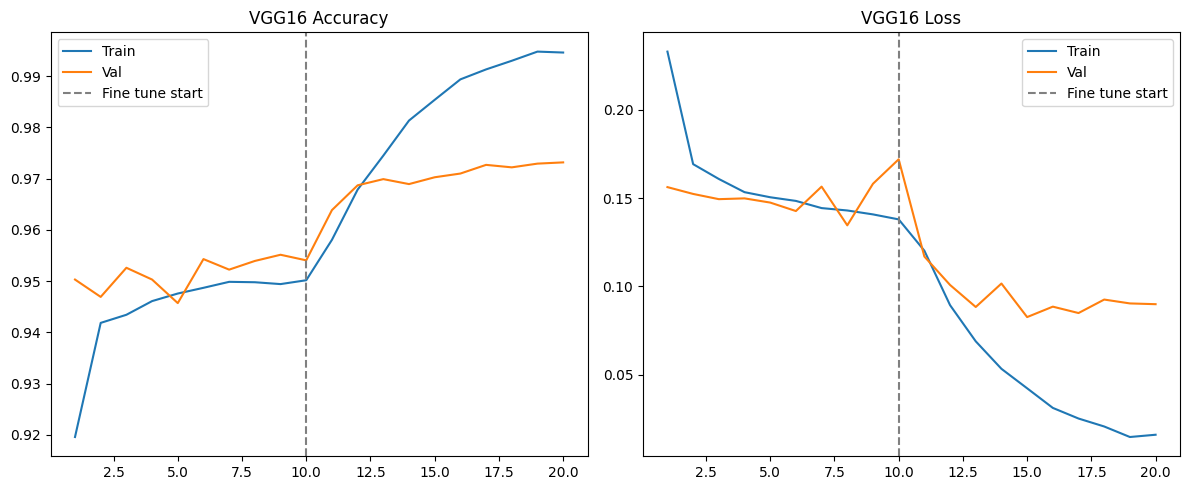


Test Loss     : 0.0962
Test Accuracy : 0.9727

Generating predictions...
517/517 ━━━━━━━━━━━━━━━━━━━━ 61s 117ms/step

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.96      0.98      0.97      4134
 Parasitized       0.98      0.96      0.97      4134

    accuracy                           0.97      8268
   macro avg       0.97      0.97      0.97      8268
weighted avg       0.97      0.97      0.97      8268



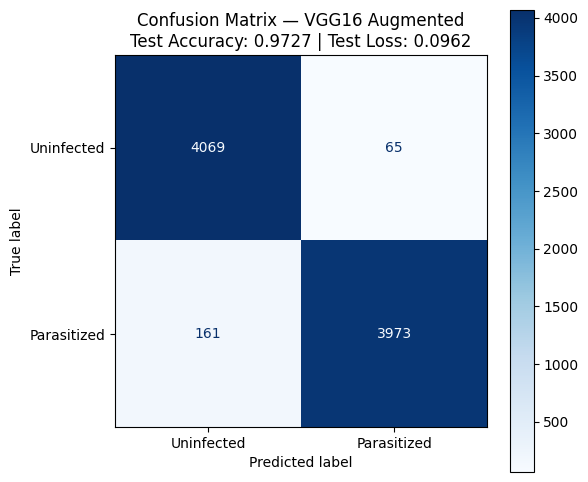

✓ Evaluation complete!


In [2]:
# VGG16 — Transfer Learning on Augmented Dataset (55,116 images)
# ═══════════════════════════════════════════════════════════════════════════
img_size   = (224, 224)
BATCH_SIZE = 16
EPOCHS     = 20
seed       = 42

df = pd.read_csv("/kaggle/working/augmented_horizontal_128.csv")
df["label"] = df["label"].astype(str)
print("Augmented dataset:")
print(df["label"].value_counts())

X_temp, X_test, y_temp, y_test = train_test_split(
    df["filepath"].values, df["label"].values,
    test_size=0.15, random_state=seed, stratify=df["label"]
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=15/85, random_state=seed, stratify=y_temp
)

train_df = pd.DataFrame({"filepath": X_train, "label": y_train})
val_df   = pd.DataFrame({"filepath": X_val,   "label": y_val})
test_df  = pd.DataFrame({"filepath": X_test,  "label": y_test})

print(f"\nTrain : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df)}  ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df)}  ({len(test_df)/len(df)*100:.1f}%)")


def vgg16_preprocess(x):
    return tf.keras.applications.vgg16.preprocess_input(x)

train_datagen = ImageDataGenerator(preprocessing_function=vgg16_preprocess)
val_datagen   = ImageDataGenerator(preprocessing_function=vgg16_preprocess)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=img_size, color_mode="rgb",
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=img_size, color_mode="rgb",
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=False
)
test_gen = val_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=img_size, color_mode="rgb",
    class_mode="binary", batch_size=BATCH_SIZE, shuffle=False
)

def build_vgg16():
    base_model = VGG16(
        input_shape=(224, 224, 3),
        include_top=False,       
        weights='imagenet'       
    )
    base_model.trainable = False  

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)  
    x = layers.Dense(256, activation='relu')(x) 
    x = layers.Dropout(0.5)(x)          
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

model, base_model = build_vgg16()
model.summary()

print(f"\nTotal params     : {model.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print("\n── Phase 1: Training top layers (base frozen) ──")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

print("\n── Phase 2: Fine tuning (last Conv block unfrozen) ──")
base_model.trainable = True

# Freeze all layers except last Conv block (block5)
for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True  
    else:
        layer.trainable = False 

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc,     label='Train')
plt.plot(epochs_range, val_acc, label='Val')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine tune start')
plt.legend(); plt.title('VGG16 Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss,     label='Train')
plt.plot(epochs_range, val_loss, label='Val')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine tune start')
plt.legend(); plt.title('VGG16 Loss')
plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

print("\nGenerating predictions...")
y_pred_prob = model.predict(test_gen, verbose=1).flatten()
y_true = np.array(test_gen.labels).astype(int)
y_pred = (y_pred_prob >= 0.5).astype(int)

class_names = ["Uninfected", "Parasitized"]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title(f"Confusion Matrix — VGG16 Augmented\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")
plt.savefig('confusion_matrix_vgg16.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Evaluation complete!")

In [ ]:
# Explainability and Interpretability
#have a robust way of make it a light weight model based on size for model deployment